# Model Evaluation and Selection
Splitting data into training, cross-validation, and test sets; comparing polynomial degrees and neural network architectures to select the best model without overfitting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler ,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

x shape: (50, 1), y shape: (50, 1)


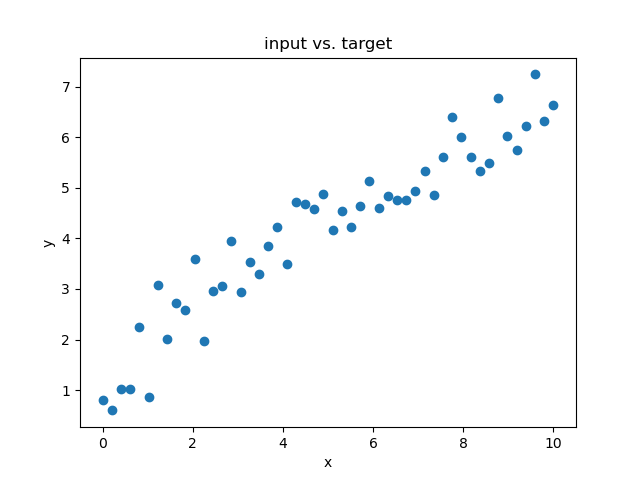

In [2]:
np.random.seed(1)
x = np.linspace(0, 10, 50).reshape(-1,1)
y = 2*np.sqrt(x) + np.random.normal(0, 0.5, size=x.shape)

print(f"x shape: {x.shape}, y shape: {y.shape}")

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("input vs. target")
plt.savefig("model_eval_data.png")
plt.close()
from IPython.display import Image
Image("model_eval_data.png")

### Split the dataset into training, cross validation, and test sets
60% training, 20% cross-validation, 20% test — CV is used to compare models, test is used only once at the end to report final performance.

In [3]:
x_train,x_,y_train,y_ = train_test_split(x,y,test_size=0.40,random_state=1)
x_cv,x_test,y_cv,y_test = train_test_split(x_,y_,test_size=0.50,random_state=1)
print(f"train: {x_train.shape[0]}, cv: {x_cv.shape[0]}, test: {x_test.shape[0]}")

train: 30, cv: 10, test: 10


### Fit a linear model
Scale features first, then train a plain linear regression model as a baseline.

In [5]:
scaler_linear = StandardScaler()
X_train_scaled = scaler_linear.fit_transform(x_train)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)

yhat = linear_model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train,yhat)/2
print(f"Training MSE: {train_mse:.4f}")

Training MSE: 0.1584


### Model selection across polynomial degrees
Try polynomial degrees 1-10, tracking training and CV MSE for each, to find the best-fitting degree without overfitting.

In [6]:
X_cv_scaled = scaler_linear.transform(x_cv)

yhat_cv = linear_model.predict(X_cv_scaled)
cv_mse = mean_squared_error(y_cv, yhat_cv) / 2
print(f"Cross Validation MSE: {cv_mse:.4f}")

Cross Validation MSE: 0.1537


### Model selection across polynomial degrees
Try polynomial degrees 1-10, tracking training and CV MSE for each, to find the best-fitting degree without overfitting.

In [20]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1, 11):
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(x_train)
    scaler = StandardScaler()
    X_train_mapped_scaled = scaler.fit_transform(X_train_mapped)

    model = LinearRegression()
    model.fit(X_train_mapped_scaled, y_train)

    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)

    x_cv_mapped = poly.transform(x_cv)
    x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
    yhat_cv = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat_cv) / 2
    cv_mses.append(cv_mse)

    models.append(model)
    polys.append(poly)
    scalers.append(scaler)

for i in range(10):
    print(f"Degree{i+1}: train_mse= {train_mses[i]:.4f}, cv_mse= {cv_mses[i]:.4f}")

Degree1: train_mse= 0.1584, cv_mse= 0.1537
Degree2: train_mse= 0.1443, cv_mse= 0.1090
Degree3: train_mse= 0.1218, cv_mse= 0.0893
Degree4: train_mse= 0.1216, cv_mse= 0.0872
Degree5: train_mse= 0.1185, cv_mse= 0.0969
Degree6: train_mse= 0.1185, cv_mse= 0.0970
Degree7: train_mse= 0.1185, cv_mse= 0.0970
Degree8: train_mse= 0.1100, cv_mse= 0.0619
Degree9: train_mse= 0.1096, cv_mse= 0.0662
Degree10: train_mse= 0.1090, cv_mse= 0.0706


In [9]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1, 11):
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(x_train)
    scaler = StandardScaler()
    X_train_mapped_scaled = scaler.fit_transform(X_train_mapped)
    
    model = LinearRegression()
    model.fit(X_train_mapped_scaled, y_train)
    
    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)
    
    X_cv_mapped = poly.transform(x_cv)
    X_cv_mapped_scaled = scaler.transform(X_cv_mapped)
    yhat_cv = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat_cv) / 2
    cv_mses.append(cv_mse)
    
    models.append(model)
    polys.append(poly)
    scalers.append(scaler)

for i in range(10):
    print(f"degree={i+1}: train_mse={train_mses[i]:.4f}, cv_mse={cv_mses[i]:.4f}")

degree=1: train_mse=0.1584, cv_mse=0.1537
degree=2: train_mse=0.1443, cv_mse=0.1090
degree=3: train_mse=0.1218, cv_mse=0.0893
degree=4: train_mse=0.1216, cv_mse=0.0872
degree=5: train_mse=0.1185, cv_mse=0.0969
degree=6: train_mse=0.1185, cv_mse=0.0970
degree=7: train_mse=0.1185, cv_mse=0.0970
degree=8: train_mse=0.1100, cv_mse=0.0619
degree=9: train_mse=0.1096, cv_mse=0.0662
degree=10: train_mse=0.1090, cv_mse=0.0706


### Select the best polynomial degree

Choose the polynomial degree with the lowest cross-validation MSE, since the CV set represents unseen data used for model selection.


In [13]:
best_degree = np.argmin(cv_mses) + 1 #returns degree index 
best_cv_mse = cv_mses[best_degree - 1] #returns the values of index

print(f"Best degree: {best_degree}")
print(f"Lowest CV MSE: {best_cv_mse:.4f}")

Best degree: 8
Lowest CV MSE: 0.0619


### Evaluate the chosen model on the test set
The test set is used only once, after model selection is complete, to report unbiased final performance.

In [16]:
X_test_mapped = polys[best_degree-1].transform(x_test)
X_test_mapped_scaled = scalers[best_degree-1].transform(X_test_mapped)

yhat_test = models[best_degree-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat_test) / 2

print(f"Training MSE: {train_mses[best_degree-1]:.4f}")
print(f"Cross Validation MSE: {cv_mses[best_degree-1]:.4f}")
print(f"Test MSE: {test_mse:.4f}")

Training MSE: 0.1100
Cross Validation MSE: 0.0619
Test MSE: 1.0629


In [17]:
print("Actual:", y_test.flatten())
print("Predicted:", yhat_test.flatten())

Actual: [6.39949786 6.63315688 6.31976585 4.76742617 5.61836794 4.22970725
 1.01366725 4.54555931 5.1307167  5.33889254]
Predicted: [ 5.56980784 10.58611281  8.42006783  4.74847855  5.83171889  3.84322051
  0.91878628  4.54925852  4.61571575  5.08880296]


### Summary
This lab implemented a proper train/cross-validation/test split for model selection. Ten polynomial degrees were trained and compared using CV MSE (never test MSE) to pick the best degree, avoiding the bias of selecting based on data the model will later be evaluated on. The test set, touched only once at the end, revealed that small test sets can produce noisy, inflated error estimates — a real limitation worth knowing when working with limited data.